# Level 1 – Task 2: Data Cleaning and Preprocessing

## Objective
The objective of this task is to clean and preprocess the Titanic dataset to make it suitable for data analysis and machine learning. Raw datasets often contain missing values, outliers, and categorical variables that need to be processed before building predictive models.

## In this task, we will:
- Load the Titanic dataset using Pandas.
- Explore the dataset structure and identify missing values.
- Handle missing data using appropriate techniques.
- Remove outliers from numerical features.
- Convert categorical variables into numerical format using Label Encoding.
- Standardize numerical features using StandardScaler.
- Save the cleaned dataset as *cleaned_titanic.csv* for further analysis.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Expected Outcome
By the end of this task, the dataset will be clean, consistent, and ready for Exploratory Data Analysis (EDA) and Machine Learning model development.

In [8]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("1) iris.csv")

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
print(df.isnull().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [6]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [7]:
df.duplicated().sum()

np.int64(3)

In [8]:
df.drop_duplicates()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


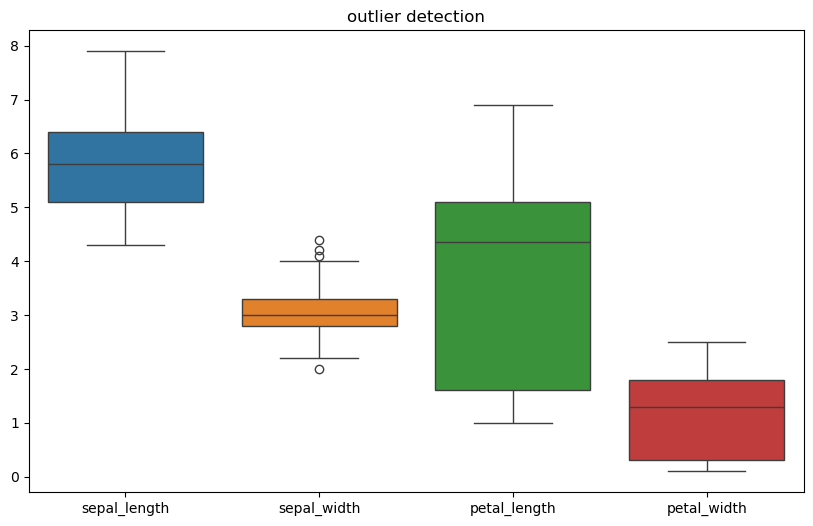

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title("outlier detection")
plt.show()

In [10]:
numeric_columns=df.select_dtypes(include=np.number).columns
Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)
IQR = Q3-Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[~((df[numeric_columns] < lower) | (df[numeric_columns] > upper)).any(axis=1)]
print("shape after removing outliers:")
df.shape

shape after removing outliers:


(146, 5)

In [11]:
le = LabelEncoder()
df["species"] = le.fit_transform(df["species"])
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
scaler=StandardScaler()
feature_columns=df.columns[:-1]
df[feature_columns] = scaler.fit_transform(df[feature_columns]) 
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,-0.910515,1.175789,-1.374878,-1.345899,0
1,-1.151122,-0.093924,-1.374878,-1.345899,0
2,-1.391729,0.413961,-1.431986,-1.345899,0
3,-1.512032,0.160019,-1.317771,-1.345899,0
4,-1.030819,1.429732,-1.374878,-1.345899,0


In [13]:
df.info()
print("\nsummary statistics")
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 146 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  146 non-null    float64
 1   sepal_width   146 non-null    float64
 2   petal_length  146 non-null    float64
 3   petal_width   146 non-null    float64
 4   species       146 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.8 KB

summary statistics


,sepal_length,sepal_width,petal_length,petal_width,species
count,1.460000e+02,1.460000e+02,1.460000e+02,1.460000e+02,146.000000
mean,7.300097e-16,-7.300097e-17,9.733462e-17,-3.406712e-16,1.020548
std,1.003442e+00,1.003442e+00,1.003442e+00,1.003442e+00,0.817643
min,-1.872943e+00,-2.125465e+00,-1.603307e+00,-1.477867e+00,0.000000
25%,-9.105154e-01,-6.018092e-01,-1.260664e+00,-1.213930e+00,0.000000
50%,-6.839165e-02,-9.392398e-02,3.383413e-01,1.057556e-01,1.000000
75%,6.534287e-01,6.679039e-01,7.380925e-01,7.655984e-01,2.000000
max,2.457980e+00,2.445502e+00,1.766024e+00,1.689378e+00,2.000000


In [14]:
df.to_csv("Cleaned_iris.csv" , index=False)
print("Dataset saved successfully as Cleaned_iris.csv")

Dataset saved successfully as Cleaned_iris.csv


In [15]:
print("Final shape of Dataset:",df.shape)
print("\nFirst Five Rows:")
print(df.head())
print("\nsummary statistics")
print(df.describe())

Final shape of Dataset: (146, 5)

First Five Rows:
   sepal_length  sepal_width  petal_length  petal_width  species
0     -0.910515     1.175789     -1.374878    -1.345899        0
1     -1.151122    -0.093924     -1.374878    -1.345899        0
2     -1.391729     0.413961     -1.431986    -1.345899        0
3     -1.512032     0.160019     -1.317771    -1.345899        0
4     -1.030819     1.429732     -1.374878    -1.345899        0

summary statistics
       sepal_length   sepal_width  petal_length   petal_width     species
count  1.460000e+02  1.460000e+02  1.460000e+02  1.460000e+02  146.000000
mean   7.300097e-16 -7.300097e-17  9.733462e-17 -3.406712e-16    1.020548
std    1.003442e+00  1.003442e+00  1.003442e+00  1.003442e+00    0.817643
min   -1.872943e+00 -2.125465e+00 -1.603307e+00 -1.477867e+00    0.000000
25%   -9.105154e-01 -6.018092e-01 -1.260664e+00 -1.213930e+00    0.000000
50%   -6.839165e-02 -9.392398e-02  3.383413e-01  1.057556e-01    1.000000
75%    6.534287e-01  